In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("库导入成功！")

库导入成功！


In [2]:
# 设置参数
n = 10000  # 每次抽取的样本量
m = 1000   # 重复次数

# 存储样本均值的数组
sample_means = np.zeros(m)

# 模拟中心极限定理
print("正在模拟，请稍候...")
for i in range(m):
    # 生成 n 个服从 U(0,1) 的随机变量
    samples = np.random.uniform(0, 1, n)
    # 计算均值并存储
    sample_means[i] = np.mean(samples)

print(f"模拟完成！")
print(f"生成了 {m} 个样本均值")
print(f"前5个均值: {sample_means[:5]}")

正在模拟，请稍候...
模拟完成！
生成了 1000 个样本均值
前5个均值: [0.50118715 0.49699916 0.49894081 0.51065122 0.50310331]


In [3]:
# 计算这些均值的实际均值和方差
actual_mean = np.mean(sample_means)
actual_variance = np.var(sample_means, ddof=0)  # 总体方差

# 理论值
theoretical_mean = 0.5  # U(0,1)的总体均值
theoretical_variance = (1/12) / n  # U(0,1)的方差是1/12，样本均值的方差是σ²/n

print("="*50)
print("统计结果：")
print("="*50)
print(f"实际样本均值的均值: {actual_mean:.6f}")
print(f"理论总体均值: {theoretical_mean}")
print(f"\n实际样本均值的方差: {actual_variance:.8f}")
print(f"理论样本均值的方差 (σ²/n): {theoretical_variance:.8f}")
print(f"\n两者相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.2f}%")

统计结果：
实际样本均值的均值: 0.500056
理论总体均值: 0.5

实际样本均值的方差: 0.00000911
理论样本均值的方差 (σ²/n): 0.00000833

两者相对误差: 9.31%


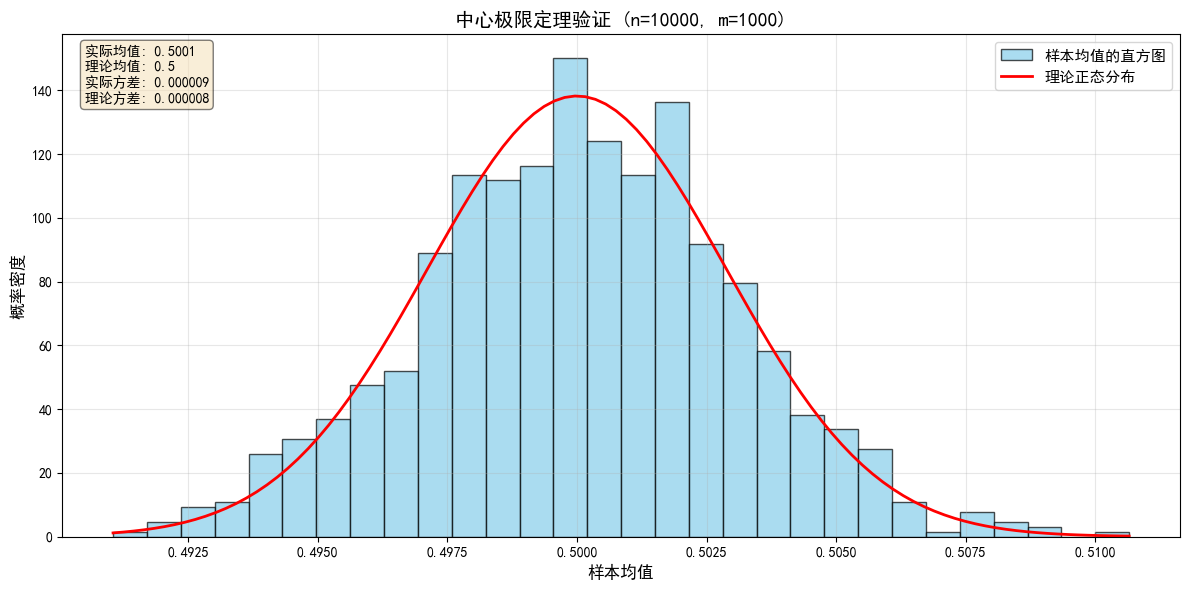

In [4]:
# 创建图形
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制直方图
count, bins, patches = ax.hist(sample_means, bins=30, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='样本均值的直方图')

# 绘制理论正态分布曲线
x = np.linspace(min(sample_means), max(sample_means), 100)
# 理论分布：N(μ, σ²/n)，其中μ=0.5，σ²=1/12
theoretical_pdf = stats.norm.pdf(x, loc=0.5, scale=np.sqrt(1/12/n))
ax.plot(x, theoretical_pdf, 'r-', linewidth=2, label='理论正态分布')

# 添加标准正态分布的Q-Q图验证（可选）
ax.set_xlabel('样本均值', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.set_title(f'中心极限定理验证 (n={n}, m={m})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 添加统计信息文本框
stats_text = f'实际均值: {actual_mean:.4f}\n理论均值: 0.5\n实际方差: {actual_variance:.6f}\n理论方差: {theoretical_variance:.6f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

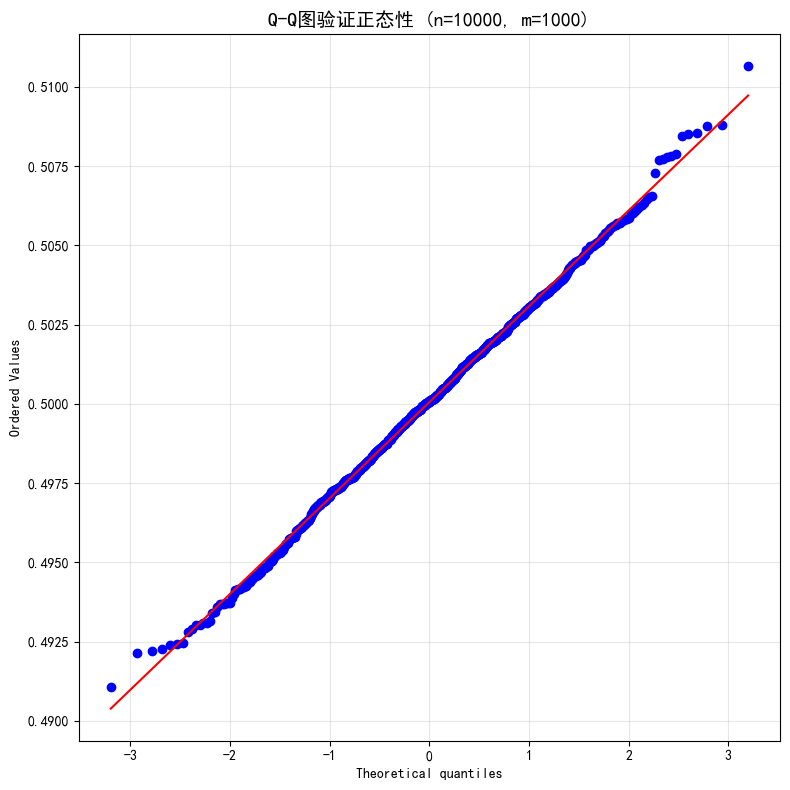

Shapiro-Wilk正态性检验:
统计量: 0.9986
p值: 0.6005
结论: 数据符合正态分布 (p > 0.05)


In [5]:
# Q-Q图验证样本均值的正态性
fig, ax = plt.subplots(figsize=(8, 8))

# 生成Q-Q图
stats.probplot(sample_means, dist="norm", plot=ax)
ax.set_title(f'Q-Q图验证正态性 (n={n}, m={m})', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 正态性检验（Shapiro-Wilk检验）
from scipy.stats import shapiro
statistic, p_value = shapiro(sample_means[:5000])  # Shapiro检验限制样本量≤5000
print(f"Shapiro-Wilk正态性检验:")
print(f"统计量: {statistic:.4f}")
print(f"p值: {p_value:.4f}")
if p_value > 0.05:
    print("结论: 数据符合正态分布 (p > 0.05)")
else:
    print("结论: 数据不符合正态分布 (p < 0.05)，但大样本下CLT仍然近似成立")